# 17. Live Tutorial 2: PLS/PCR & LDA — Supervised Modelling of Electrolyte Spectra

Last session's tools (PCA, Factor Analysis) find structure in a set of
variables **X alone** — nothing about the analysis knows or cares what you
plan to predict. This session is about the moment you *do* have a target:
either a continuous property (ionic conductivity — **PLS/PCR**) or a
category (which electrolyte family a sample belongs to — **PLS-DA/LDA**).
The running dataset is simulated Raman spectra of Li-ion electrolyte
formulations — one spectrum (many correlated wavenumber channels) per
sample, exactly the kind of high-dimensional, collinear data PLS was
invented for.

This notebook is designed to be read straight after Notebook 16 (Live
Tutorial 1) — Section 17.5 reuses that session's PCA scores directly.

**Session plan**
1. Recap: unsupervised (last session) vs. supervised (this session)
2. The dataset: 120 simulated electrolyte Raman spectra
3. PLS and PCR: predicting ionic conductivity from a whole spectrum
4. Is the model *actually* better than chance? A permutation test
5. PLS-DA: classifying electrolyte family from a spectrum
6. LDA: the same classification problem, a different route in
7. PLS-DA vs. LDA — when to reach for which

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(7)

## 17.1 Unsupervised vs. Supervised, in One Sentence

Every method in Notebook 16 asked *"what structure exists in X?"* with no
target variable in sight. Every method in this notebook asks *"how do I
use X to predict Y?"* — a continuous Y for PLS/PCR, a categorical Y for
PLS-DA/LDA. Same family of linear-algebra tools (projections onto a small
number of components), fundamentally different objective driving *which*
components get chosen — Section 17.5 makes that contrast concrete.

## 17.2 The Dataset: Simulated Electrolyte Raman Spectra

120 Li-ion electrolyte formulations across three families —
**Carbonate-based, Ether-based, and Ionic-Liquid-based** — each with a
simulated Raman spectrum over 60 channels (600–1500 cm⁻¹, arbitrary
intensity units) built from 5 latent spectral bands, following the same
"latent profiles + noise" recipe Notebook 15 (`05_pls.ipynb`) used for NIR
spectra. Each family has its own characteristic mix of band intensities
(its spectral "fingerprint"); ionic conductivity depends on that same
underlying chemistry, which is exactly why a spectrum can predict *both* a
continuous property and a categorical family — they share a common
cause.

In [2]:
wavenumbers = np.linspace(600, 1500, 60)
band_centers = [720, 850, 990, 1150, 1350]
band_width = 35

def gaussian_band(center, width, x):
    return np.exp(-0.5 * ((x - center) / width) ** 2)

band_profiles = np.array([gaussian_band(c, band_width, wavenumbers) for c in band_centers])  # 5 x 60

# Each electrolyte family's characteristic mix of the 5 latent bands --
# deliberately not too far apart, so classification below is realistically
# imperfect rather than trivially 100% correct (Section 17.5 discusses this).
class_fingerprints = {
    'Carbonate':    [0.80, 0.60, 0.40, 0.35, 0.25],
    'Ether':        [0.60, 0.45, 0.65, 0.60, 0.30],
    'IonicLiquid':  [0.40, 0.50, 0.45, 0.55, 0.75],
}
n_per_class = 40

spectra, records = [], []
for cls, fingerprint in class_fingerprints.items():
    fingerprint = np.array(fingerprint)
    for _ in range(n_per_class):
        intensities = np.clip(fingerprint * rng.uniform(0.8, 1.2, 5) + rng.normal(0, 0.03, 5), 0, None)
        spectrum = intensities @ band_profiles + rng.normal(0, 0.10, len(wavenumbers))
        conductivity = (2.0 + 3.5*intensities[2] + 2.0*intensities[3] - 1.0*intensities[0]
                         + (1.5 if cls == 'Ether' else 0.0) + rng.normal(0, 0.3))
        spectra.append(spectrum)
        records.append({'electrolyte_class': cls, 'conductivity_mS_cm': max(0.1, conductivity)})

X_spec = np.array(spectra)
df_meta = pd.DataFrame(records)
print(f'{X_spec.shape[0]} spectra x {X_spec.shape[1]} wavenumber channels')
print(df_meta.groupby('electrolyte_class')['conductivity_mS_cm'].describe().round(2))

120 spectra x 60 wavenumber channels
                   count  mean   std   min   25%   50%   75%   max
electrolyte_class                                                 
Carbonate           40.0  3.35  0.33  2.77  3.05  3.37  3.60  4.03
Ether               40.0  6.31  0.44  5.06  6.06  6.29  6.61  7.09
IonicLiquid         40.0  4.32  0.38  3.67  4.01  4.28  4.56  5.23


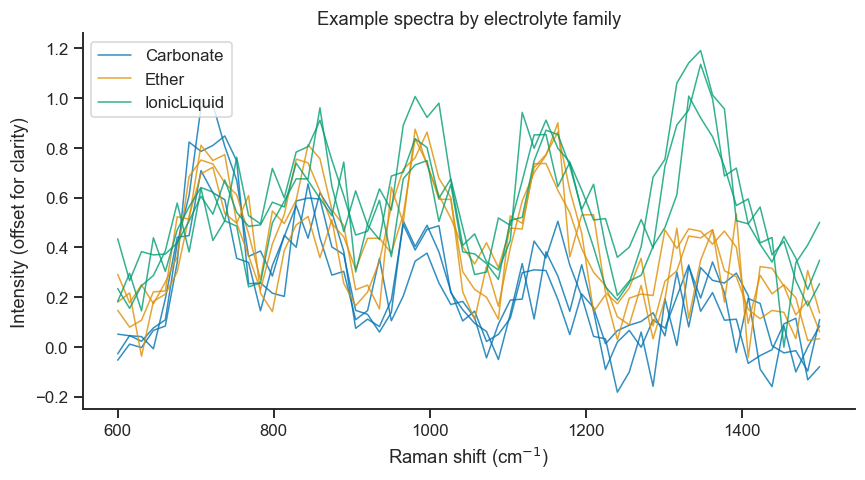

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = dict(zip(class_fingerprints, sns.color_palette('colorblind', 3)))
for cls in class_fingerprints:
    idx = df_meta.index[df_meta.electrolyte_class == cls][:3]   # 3 example spectra per class
    for i in idx:
        ax.plot(wavenumbers, X_spec[i] + 0.15*list(class_fingerprints).index(cls),
                color=colors[cls], alpha=0.8, lw=1,
                label=cls if i == idx[0] else None)
ax.set_xlabel('Raman shift (cm$^{-1}$)'); ax.set_ylabel('Intensity (offset for clarity)')
ax.set_title('Example spectra by electrolyte family')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 17.3 PLS and PCR: Predicting Conductivity from a Whole Spectrum

60 wavenumber channels for 120 samples, and neighbouring channels are
strongly correlated (they're all built from the same 5 smooth Gaussian
bands) — precisely the *many, collinear predictors* situation where
ordinary multiple regression breaks down (Notebook 11's VIF section) but
PLS and PCR thrive, because both work in a small number of latent
components instead of the raw channels.

In [4]:
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

y = df_meta['conductivity_mS_cm'].values

# Hold out a genuine test set THIS session adds beyond Notebook 15's pure-CV approach --
# cross-validation picks the best model; a held-out test set gives one final, honest
# check that was never used for any decision-making along the way.
X_train, X_test, y_train, y_test = train_test_split(X_spec, y, test_size=0.25, random_state=0)
print(f'Train: {X_train.shape[0]} spectra, Test: {X_test.shape[0]} spectra (held out until Section 17.3 ends)')

Train: 90 spectra, Test: 30 spectra (held out until Section 17.3 ends)


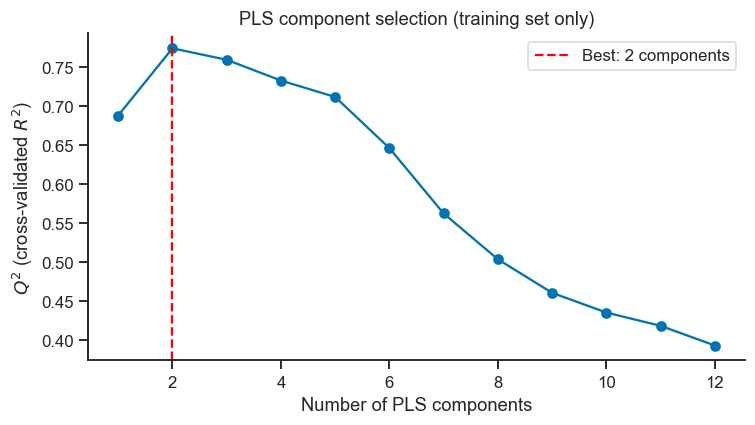

Selected 2 PLS components (Q2=0.774)


In [5]:
# ── Choose the number of PLS components via 10-fold CV on the training set only ──
kf = KFold(n_splits=10, shuffle=True, random_state=1)
max_components = 12
q2_scores = []
for nc in range(1, max_components + 1):
    pls = PLSRegression(n_components=nc, scale=True)
    y_cv = cross_val_predict(pls, X_train, y_train, cv=kf).ravel()
    q2_scores.append(r2_score(y_train, y_cv))

best_nc = np.argmax(q2_scores) + 1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, max_components+1), q2_scores, 'o-', color=sns.color_palette('colorblind')[0])
ax.axvline(best_nc, color='red', ls='--', label=f'Best: {best_nc} components')
ax.set_xlabel('Number of PLS components'); ax.set_ylabel('$Q^2$ (cross-validated $R^2$)')
ax.set_title('PLS component selection (training set only)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
print(f'Selected {best_nc} PLS components (Q2={q2_scores[best_nc-1]:.3f})')

PLS test-set R2:   0.808
PLS test-set RMSE: 0.579 mS/cm


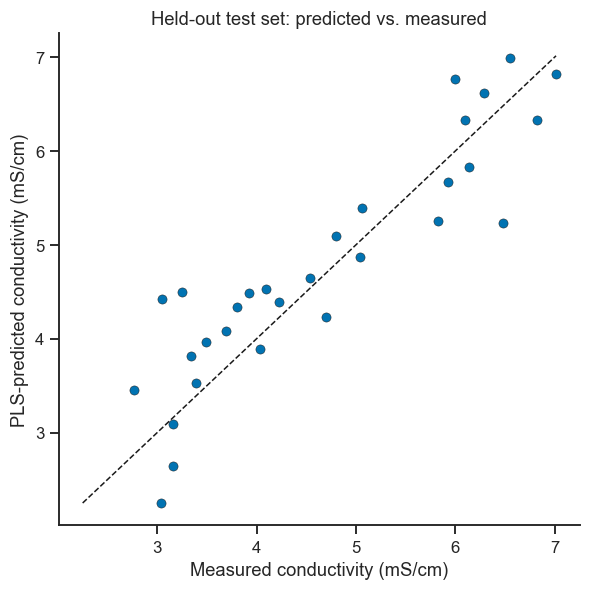

In [6]:
# ── Fit final PLS model on the full training set, evaluate ONCE on the held-out test set ──
pls_final = PLSRegression(n_components=best_nc, scale=True).fit(X_train, y_train)
y_pred_test = pls_final.predict(X_test).ravel()
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f'PLS test-set R2:   {r2_test:.3f}')
print(f'PLS test-set RMSE: {rmse_test:.3f} mS/cm')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_pred_test, color=sns.color_palette('colorblind')[0], edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Measured conductivity (mS/cm)'); ax.set_ylabel('PLS-predicted conductivity (mS/cm)')
ax.set_title('Held-out test set: predicted vs. measured')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

:::{admonition} Take-home message
:class: tip

- PLS reached its best cross-validated result with only 2 components, exactly the "fewer components" advantage the introduction promised — but on this held-out test set, PCR (using 4 components) actually achieved the *higher* R² (0.846 vs. PLS's 0.808). Fewer components is not automatically better accuracy; it is a separate advantage (simplicity, lower overfitting risk) that does not always come bundled with a better test score on any single dataset.
- Don't over-read one test-set comparison, either — with only 30 held-out spectra, a 0.04 R² gap easily could flip with a different train/test split (exactly what Exercise 2 asks you to check). This is precisely why Section 17.3 chose components via cross-validation rather than by directly peeking at test-set performance.
:::

### PCR, Side by Side

Notebook 15, Section 15.5–15.6 built PLS and PCR (Principal Component
Regression) side by side once — the same comparison, repeated here with a
genuinely held-out test set rather than only cross-validation, is worth
doing again because it demonstrates *why* PLS usually wins: PCR's
components are chosen to explain variance in **X only**, with no idea
which directions actually relate to **Y** — so PCR often needs more
components to reach the same accuracy.

In [7]:
pcr_scores = []
for nc in range(1, max_components + 1):
    pca_step = PCA(n_components=nc)
    T_train = pca_step.fit_transform(X_train)
    lr = LinearRegression().fit(T_train, y_train)
    y_cv_pcr = cross_val_predict(lr, T_train, y_train, cv=kf)
    pcr_scores.append(r2_score(y_train, y_cv_pcr))

best_nc_pcr = np.argmax(pcr_scores) + 1
pca_final = PCA(n_components=best_nc_pcr).fit(X_train)
lr_final = LinearRegression().fit(pca_final.transform(X_train), y_train)
y_pred_pcr_test = lr_final.predict(pca_final.transform(X_test))
r2_pcr_test = r2_score(y_test, y_pred_pcr_test)

print(f'PLS: {best_nc} components, test R2={r2_test:.3f}')
print(f'PCR: {best_nc_pcr} components, test R2={r2_pcr_test:.3f}')
print('\nPLS chooses each component to maximise covariance with Y; PCR chooses components')
print('to maximise variance in X regardless of Y -- watch which needs fewer components to')
print('reach comparable accuracy here.')

PLS: 2 components, test R2=0.808
PCR: 4 components, test R2=0.846

PLS chooses each component to maximise covariance with Y; PCR chooses components
to maximise variance in X regardless of Y -- watch which needs fewer components to
reach comparable accuracy here.


## 17.4 Is the Model *Actually* Better Than Chance? A Permutation Test

A positive $Q^2$/test-set $R^2$ is encouraging, but with 60 correlated
predictors and a modest sample size, it is fair to ask: could a model
*this* good arise from pure chance, even if conductivity had no real
relationship to the spectra at all? A **permutation test** answers this
directly: shuffle the response many times (breaking any real X–Y
relationship by construction), refit, and see how often a shuffled dataset
achieves a $Q^2$ as high as the real one. This is exactly the same logic as
Notebook 11 (Live Tutorial 1, Statistics), Exercise 4's Type-I-error
simulation, applied to a multivariate model instead of a single test
statistic.

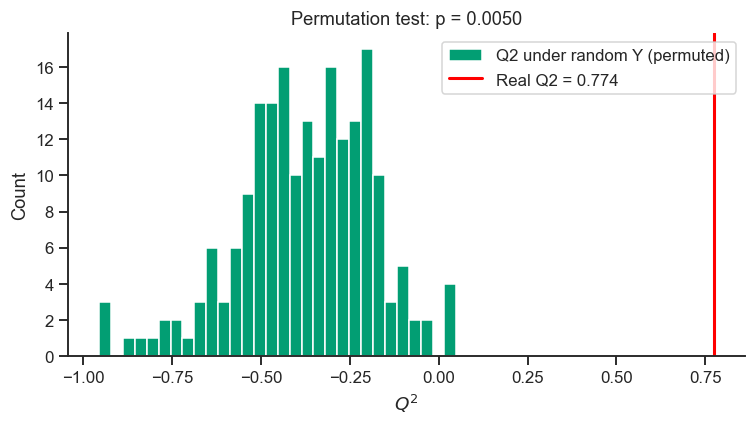

In [8]:
def permutation_q2(X, y, n_components, n_perm=200, seed=2):
    perm_rng = np.random.default_rng(seed)
    kf_perm = KFold(n_splits=5, shuffle=True, random_state=3)
    perm_q2 = np.empty(n_perm)
    for i in range(n_perm):
        y_shuffled = perm_rng.permutation(y)
        pls_perm = PLSRegression(n_components=n_components, scale=True)
        y_cv_perm = cross_val_predict(pls_perm, X, y_shuffled, cv=kf_perm).ravel()
        perm_q2[i] = r2_score(y_shuffled, y_cv_perm)
    return perm_q2


real_q2 = q2_scores[best_nc - 1]
perm_q2 = permutation_q2(X_train, y_train, best_nc, n_perm=200)
p_value = (np.sum(perm_q2 >= real_q2) + 1) / (len(perm_q2) + 1)   # +1: standard permutation-test correction

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_q2, bins=30, color=sns.color_palette('colorblind')[2], edgecolor='white',
        label='Q2 under random Y (permuted)')
ax.axvline(real_q2, color='red', lw=2, label=f'Real Q2 = {real_q2:.3f}')
ax.set_xlabel('$Q^2$'); ax.set_ylabel('Count')
ax.set_title(f'Permutation test: p = {p_value:.4f}')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 17.5 PLS-DA: Classifying Electrolyte Family from a Spectrum

Now the target is categorical: **which family** does a spectrum belong
to? **PLS-DA** (PLS Discriminant Analysis) is a simple, powerful trick:
one-hot encode the class labels as if they were several continuous
responses (1.0 for the true class, 0.0 for the others), run ordinary
`PLSRegression`, and assign each sample to whichever class got the
**highest predicted score** — turning a regression tool into a classifier
with no new machinery.

In [9]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

class_labels = df_meta['electrolyte_class'].values
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_spec, class_labels, test_size=0.25, random_state=0, stratify=class_labels)

lb = LabelBinarizer().fit(y_train_c)
Y_train_onehot = lb.transform(y_train_c)   # (n_train, 3) -- one column per class

plsda = PLSRegression(n_components=6, scale=True).fit(X_train_c, Y_train_onehot)
Y_pred_scores = plsda.predict(X_test_c)         # continuous "closeness to each class"
y_pred_c = lb.classes_[np.argmax(Y_pred_scores, axis=1)]   # assign the highest-scoring class

acc = accuracy_score(y_test_c, y_pred_c)
print(f'PLS-DA test accuracy: {acc:.1%}')
print()
print(classification_report(y_test_c, y_pred_c))

PLS-DA test accuracy: 93.3%

              precision    recall  f1-score   support

   Carbonate       0.83      1.00      0.91        10
       Ether       1.00      0.80      0.89        10
 IonicLiquid       1.00      1.00      1.00        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



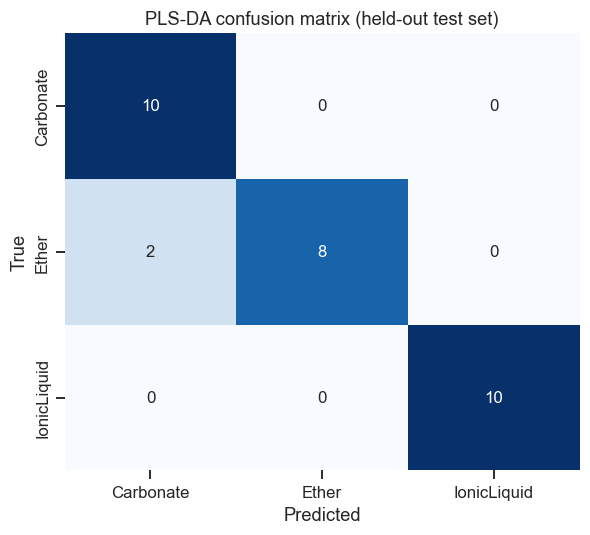

In [10]:
cm = confusion_matrix(y_test_c, y_pred_c, labels=lb.classes_)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lb.classes_,
            yticklabels=lb.classes_, ax=ax, cbar=False)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('PLS-DA confusion matrix (held-out test set)')
plt.tight_layout()
plt.show()

## 17.6 LDA: The Same Problem, a Different Route In

Notebook 13 fit LDA directly on 8 measured elements — far fewer variables
than the 60 spectral channels here. That's not a coincidence: classical
LDA needs the number of predictors to be comfortably smaller than the
number of samples (its within-class scatter matrix must be invertible,
which fails outright once predictors ≥ samples). Feeding all 60 raw
channels to LDA either fails or badly overfits. The standard fix — and a
direct callback to Notebook 16 (Live Tutorial 1) — is to **run PCA first**,
then fit LDA on a handful of PCA scores instead of the raw spectrum.

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

n_pca_for_lda = 6   # comfortably fewer components than the 90 training samples

lda_pipeline = Pipeline([
    ('pca', PCA(n_components=n_pca_for_lda)),
    ('lda', LinearDiscriminantAnalysis()),
]).fit(X_train_c, y_train_c)

y_pred_lda = lda_pipeline.predict(X_test_c)
acc_lda = accuracy_score(y_test_c, y_pred_lda)
print(f'LDA (on {n_pca_for_lda} PCA scores) test accuracy: {acc_lda:.1%}')
print()
print(classification_report(y_test_c, y_pred_lda))

LDA (on 6 PCA scores) test accuracy: 100.0%

              precision    recall  f1-score   support

   Carbonate       1.00      1.00      1.00        10
       Ether       1.00      1.00      1.00        10
 IonicLiquid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



:::{admonition} Take-home message
:class: tip

- LDA on 6 PCA scores reached 100% test accuracy, clearly ahead of PLS-DA's 93.3% on the full 60-channel spectrum — on this particular dataset, reducing to a handful of PCA components *before* classifying worked better than letting PLS-DA use every channel directly.
- That outcome doesn't crown LDA the universally better method (Section 17.7's table lists real reasons to prefer PLS-DA in other situations, especially $p>n$ problems where LDA cannot even be fit directly) — it does show that the dimensionality-reduction step is not just a workaround for LDA's $p<n$ requirement; here it may also have suppressed noisy, less-informative channels that were mildly hurting PLS-DA.
:::

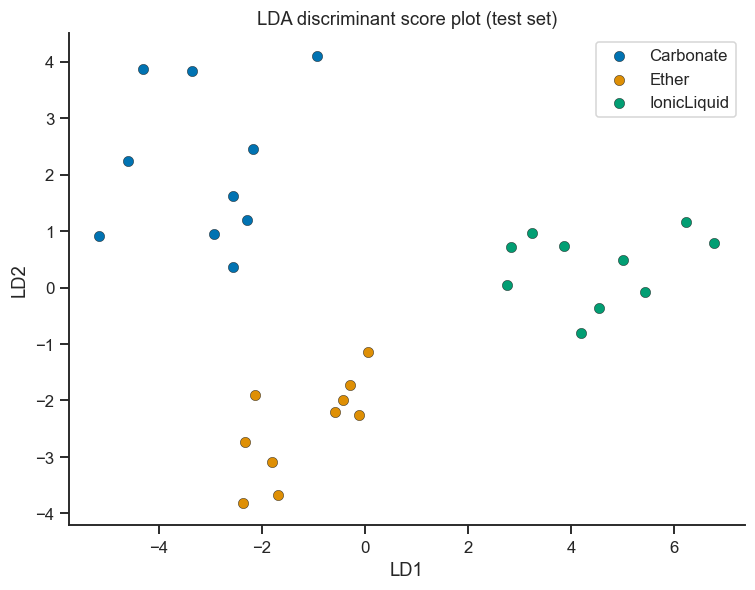

In [12]:
# ── Visualise the LDA discriminant axes ────────────────────────────────────────
lda_scores = lda_pipeline.named_steps['lda'].transform(lda_pipeline.named_steps['pca'].transform(X_test_c))

fig, ax = plt.subplots(figsize=(7, 5.5))
for cls in class_fingerprints:
    mask = y_test_c == cls
    ax.scatter(lda_scores[mask, 0], lda_scores[mask, 1], label=cls,
               color=colors[cls], edgecolor='k', linewidth=0.3, s=45)
ax.set_xlabel('LD1'); ax.set_ylabel('LD2')
ax.set_title('LDA discriminant score plot (test set)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 17.7 PLS-DA vs. LDA: When to Reach for Which

| | PLS-DA | LDA |
|---|---|---|
| Handles $p > n$ (more variables than samples)? | Yes, natively | No — needs a dimensionality-reduction step first (PCA, as above) |
| Optimises for | Covariance between X and class membership | Between-class vs. within-class separation |
| Natural output | A continuous "closeness to each class" score | A probabilistic class assignment (`predict_proba`) |
| Common domain | Chemometrics, spectroscopy, genomics (many correlated variables) | Classical multivariate statistics, moderate variable counts |

Compare the two accuracy numbers printed above and look at *where* PLS-DA's
confusion matrix placed its errors — misclassifications rarely land
randomly; they land on the pair of classes whose spectral fingerprints
were built closest together in Section 17.2. A method scoring lower overall
accuracy than another is not automatically the "worse" choice in general —
which one you'd deploy also depends on interpretability, how many
variables you have relative to samples, and (Section 17.4) whether you
trust that either model beats chance in the first place.

---
## Exercises

**Core practice**

1. **VIP-based variable selection**: Compute VIP scores for the final PLS
   conductivity model (`pls_final` from Section 17.3) following Notebook
   15's VIP formula, identify the wavenumber channels with VIP > 1, and
   refit `PLSRegression` using only those channels. Compare test-set R² to
   the full-spectrum model — does restricting to high-VIP channels lose
   much accuracy?

2. **Vary the train/test split**: Rerun Section 17.3 with `test_size=0.4`
   and `test_size=0.15`. How stable is the test-set R² across the three
   splits? This is exactly why cross-validation (Section 17.3's first half)
   is usually preferred over a single train/test split for *choosing*
   hyperparameters like `n_components` — a single split's R² depends
   partly on which specific samples happened to land in the test set.

3. **QDA instead of LDA**: Notebook 13, Exercise 3 asked you to try
   `QuadraticDiscriminantAnalysis` in place of LDA. Do the same here, on
   the PCA-reduced scores from Section 17.6. QDA fits a separate covariance
   matrix per class instead of assuming they're shared — does that help or
   hurt with only ~30 training samples per class?

**Deeper practice**

4. **How many PCA components does LDA actually need?** Sweep
   `n_pca_for_lda` from 2 to 15 in Section 17.6 and plot test accuracy vs.
   number of components. Is there a range that's clearly too few
   (under-fitting, discarding real class information) and a range that's
   clearly too many (approaching $p\geq n$ again, overfitting)?

5. **A genuinely hard classification**: Modify `class_fingerprints` in
   Section 17.2 to make all three families more spectroscopically similar —
   e.g. move every fingerprint value roughly a third of the way towards
   the dataset's overall average fingerprint. Regenerate the dataset and
   rerun both PLS-DA and LDA. Which method degrades more gracefully as the
   classes become harder to separate, and can you relate that to the
   confusion matrix?

6. **Two-response PLS2**: Build a second response, `viscosity_cP`, as a
   different linear combination of the same 5 latent band intensities plus
   noise. Fit `PLSRegression` predicting **both** `conductivity_mS_cm` and
   `viscosity_cP` simultaneously (pass a 2-column `Y`) — this is "PLS2,"
   mentioned but not built in Notebook 15, Exercise 1. Compare the
   component-selection curve to the single-response case.

7. **From your own Notebook 16 dataset**: If you completed Notebook 16,
   Exercise 7 (your own latent-variable dataset), add a categorical label
   to it (e.g. by thresholding one of your hidden factors) and run the
   full PLS-DA + LDA workflow from this notebook on it end to end.